# Assignment 1: Linear Algebra Foundations and MVN Testing

**STA437 | Winter 2026**

This notebook provides scaffolding for Assignment 1. Complete each section and record your answers for Quercus submission.

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin

np.set_printoptions(precision=4, suppress=True)

In [165]:
# Load Palmer Penguins dataset
penguins = sns.load_dataset('penguins').dropna()
print(f"n = {len(penguins)}")

# Select numeric variables
numeric_vars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[numeric_vars].values
n, p = X.shape
print(f"Shape: {n} x {p}")

n = 333
Shape: 333 x 4


---
## Q1: Unstandardized Covariance Matrix

Compute the sample covariance matrix and generate a heatmap.

**Useful functions:** `np.cov()`, `sns.heatmap()`

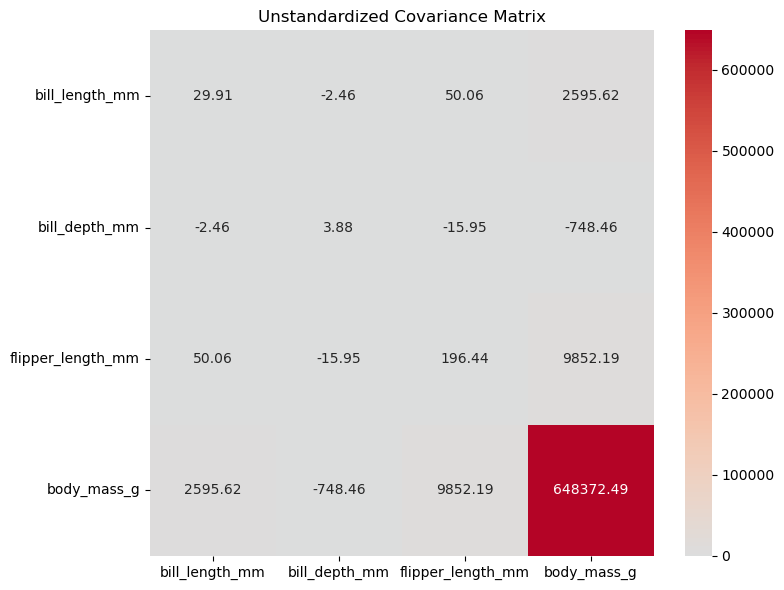

In [166]:
cov_unstandardized = np.cov(X, rowvar=False)

# Generate heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_unstandardized, annot=True, fmt='.2f', 
            xticklabels=numeric_vars, yticklabels=numeric_vars,
            cmap='coolwarm', center=0)
plt.title('Unstandardized Covariance Matrix')
plt.tight_layout()
plt.show()


---
## Q2: Largest Eigenvalue (Unstandardized)

Compute eigenvalues of the unstandardized covariance matrix.

**Useful functions:** `np.linalg.eigh()` (returns eigenvalues in ascending order)

In [167]:
# Compute eigenvalues and eigenvectors
eigenvalues_unstandardized, eigenvectors_unstandardized = np.linalg.eigh(cov_unstandardized)

# Largest eigenvalue (unstandardized)
largest_eigenvalue_unstd = eigenvalues_unstandardized[-1]
print(f"Largest eigenvalue (unstandardized): {largest_eigenvalue_unstd:.4f}")



Largest eigenvalue (unstandardized): 648533.4619


---
## Q3: Standardized Covariance Matrix

Standardize the data (subtract mean, divide by std), then compute covariance and generate a heatmap.

**Useful functions:** `X.mean()`, `X.std()`, `np.cov()`

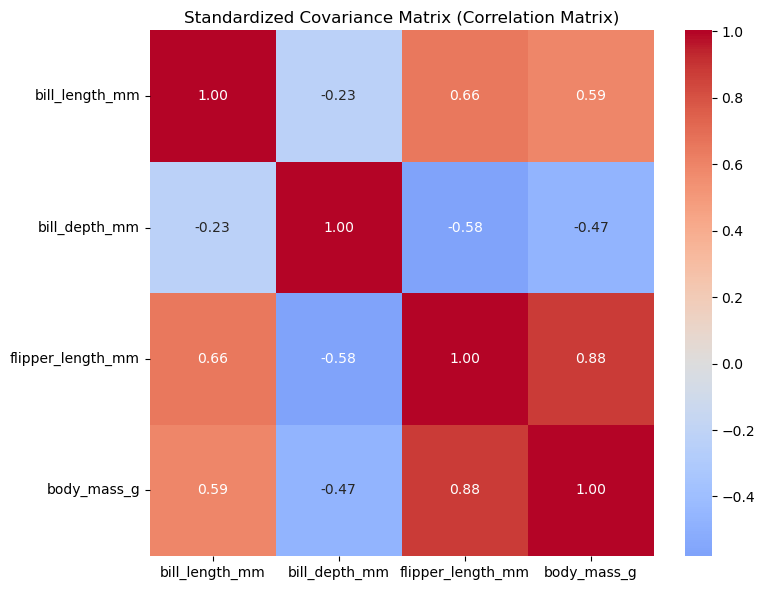

In [168]:
# Standardize the data (subtract mean, divide by std)
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0)

# Compute standardized covariance matrix
cov_standardized = np.cov(X_standardized, rowvar=False)

# Generate heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_standardized, annot=True, fmt='.2f', 
            xticklabels=numeric_vars, yticklabels=numeric_vars,
            cmap='coolwarm', center=0)
plt.title('Standardized Covariance Matrix (Correlation Matrix)')
plt.tight_layout()
plt.show()

---
## Q4: PC1 Loading (Standardized Data)

Find which variable has the strongest loading (largest absolute value) on PC1.

**Hint:** The eigenvector corresponding to the largest eigenvalue gives the PC1 loadings.

In [169]:
# Compute eigenvalues and eigenvectors of standardized covariance matrix
eigenvalues_standardized, eigenvectors_standardized = np.linalg.eigh(cov_standardized)

# Get PC1 (largest eigenvalue and corresponding eigenvector)
pc1_eigenvalue = eigenvalues_standardized[-1]
pc1_loadings = eigenvectors_standardized[:, -1]

print(f"Largest eigenvalue (PC1): {pc1_eigenvalue:.4f}")
print(f"PC1 loadings: {pc1_loadings}")

# Find variable with strongest loading (largest absolute value)
strongest_loading_idx = np.argmax(np.abs(pc1_loadings))
strongest_loading_var = numeric_vars[strongest_loading_idx]
strongest_loading_value = pc1_loadings[strongest_loading_idx]

print(f"\nVariable with strongest loading on PC1: {strongest_loading_var}")
print(f"Loading value: {strongest_loading_value:.4f}")


Largest eigenvalue (PC1): 2.7536
PC1 loadings: [-0.4538  0.399  -0.5768 -0.5497]

Variable with strongest loading on PC1: flipper_length_mm
Loading value: -0.5768


---
## Q5: Components for 90% Variance

Calculate cumulative variance explained from the standardized covariance eigenvalues.

**Useful functions:** `np.cumsum()`

In [170]:
# Sort eigenvalues descending for variance explained
sorted_eigenvalues = np.sort(eigenvalues_standardized)[::-1]
variance_explained = sorted_eigenvalues / np.sum(sorted_eigenvalues)
print(variance_explained)

cum_variance_explained = np.cumsum(variance_explained)
print(cum_variance_explained)

components_for_90 = np.argmax(cum_variance_explained >= 0.90) + 1
print("Number of components for 90% variance:", components_for_90)

[0.6863 0.1945 0.0922 0.027 ]
[0.6863 0.8809 0.973  1.    ]
Number of components for 90% variance: 3


---
## Q6: Mardia's Test

Run Mardia's test for multivariate normality.

**Options:**
- Use `pingouin.multivariate_normality()` if installed (`pip install pingouin`)
- Compute Mardia's skewness and kurtosis manually using the formulas from class

**Mardia's skewness:** $b_{1,p} = \frac{1}{n^2} \sum_{i,j} [(\mathbf{x}_i - \bar{\mathbf{x}})' \mathbf{S}^{-1} (\mathbf{x}_j - \bar{\mathbf{x}})]^3$

**Mardia's kurtosis:** $b_{2,p} = \frac{1}{n} \sum_{i} [(\mathbf{x}_i - \bar{\mathbf{x}})' \mathbf{S}^{-1} (\mathbf{x}_i - \bar{\mathbf{x}})]^2$

In [171]:
#help(pingouin.multivariate_normality)
hz, pval, normal = pingouin.multivariate_normality(X)
print(hz)
print(pval)
print(normal)


5.103462626283741
4.0498788850656005e-67
False


---
## Q7: Hotelling's T-squared Test

Compare mean vectors of Adelie vs Chinstrap penguins.

**Formula:** $T^2 = \frac{n_1 n_2}{n_1 + n_2} (\bar{\mathbf{x}}_1 - \bar{\mathbf{x}}_2)' \mathbf{S}_{\text{pooled}}^{-1} (\bar{\mathbf{x}}_1 - \bar{\mathbf{x}}_2)$

**Conversion to F:** $F = T^2 \cdot \frac{n_1 + n_2 - p - 1}{p(n_1 + n_2 - 2)}$ with df $(p, n_1 + n_2 - p - 1)$

In [172]:
# Separate by species
species = penguins['species'].values
X_adelie = X[species == 'Adelie']
X_chinstrap = X[species == 'Chinstrap']

# Your code here
# Sample sizes
n_adelie = len(X_adelie)
n_chinstrap = len(X_chinstrap)

# Covariance matrices
S_adelie = np.cov(X_adelie, rowvar=False)
S_chinstrap = np.cov(X_chinstrap, rowvar=False)

# Pooled covariance
S_pooled = ((n_adelie - 1) * S_adelie + (n_chinstrap - 1) * S_chinstrap)\
     / (n_adelie + n_chinstrap - 2)

# Mean difference
mean_diff = X_adelie.mean(axis=0) - X_chinstrap.mean(axis=0)

# Hotelling's T-squared
T_2 = (n_adelie * n_chinstrap) / (n_adelie + n_chinstrap) * mean_diff.T @ np.linalg.inv(S_pooled) @ mean_diff

# Calculate F-statistic
p = X.shape[1]
F_stat = T_2 * (n_adelie + n_chinstrap - p - 1) / (p * (n_adelie + n_chinstrap - 2))
df1 = p
df2 = n_adelie + n_chinstrap - p - 1
p_value = 1 - stats.f.cdf(F_stat, df1, df2)

print(f"T-squared: {T_2:.4f}")
print(f"F-statistic: {F_stat:.4f}")
print(f"Degrees of freedom: ({df1}, {df2})")
print(f"p-value: {p_value:.6f}")


T-squared: 804.4540
F-statistic: 198.2676
Degrees of freedom: (4, 209)
p-value: 0.000000


---
## Q8: Mahalanobis Q-Q Plot

Compute squared Mahalanobis distances and create a Q-Q plot against chi-square quantiles.

**Mahalanobis distance:** $d_i^2 = (\mathbf{x}_i - \bar{\mathbf{x}})' \mathbf{S}^{-1} (\mathbf{x}_i - \bar{\mathbf{x}})$

**Theoretical quantiles:** `stats.chi2.ppf((i - 0.5)/n, df=p)` for $i = 1, \ldots, n$

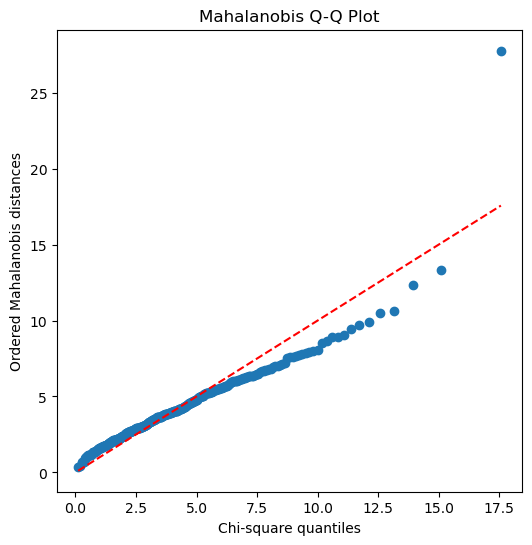

In [173]:
# Center the data
X_centered = X - X.mean(axis=0)
S_inv = np.linalg.inv(np.cov(X, rowvar=False))
d2 = np.sum(X_centered @ S_inv * X_centered, axis=1) 


theoretical = stats.chi2.ppf((np.arange(1, n+1) - 0.5) / n, df=p)

plt.figure(figsize=(6, 6))
plt.scatter(theoretical, np.sort(d2))
plt.plot([theoretical.min(), theoretical.max()],
         [theoretical.min(), theoretical.max()],
         'r--')
plt.xlabel('Chi-square quantiles')
plt.ylabel('Ordered Mahalanobis distances')
plt.title('Mahalanobis Q-Q Plot')
plt.show()

---
## Q9: Per-Species Eigenvector Comparison

For each species separately:
1. Standardize the data within that species
2. Compute the covariance matrix
3. Find PC1 loadings

Compare which variable has the most consistent loading across species.

In [178]:
species = penguins['species'].values
X_adelie = X[species == 'Adelie']
X_chinstrap = X[species == 'Chinstrap']
X_gentoo = X[species == 'Gentoo']

# Standardize within species  
X_adelie_std = (X_adelie - X_adelie.mean(axis=0)) / X_adelie.std(axis=0)
X_chinstrap_std = (X_chinstrap - X_chinstrap.mean(axis=0)) / X_chinstrap.std(axis=0)
X_gentoo_std = (X_gentoo - X_gentoo.mean(axis=0)) / X_gentoo.std(axis=0)

# Compute covariance matrices
S_adelie = np.cov(X_adelie_std, rowvar=False)
S_chinstrap = np.cov(X_chinstrap_std, rowvar=False)
S_gentoo = np.cov(X_gentoo_std, rowvar=False)

# Compute PC1 loadings  
eigenvalues_adelie, eigenvectors_adelie = np.linalg.eigh(S_adelie)
eigenvalues_chinstrap, eigenvectors_chinstrap = np.linalg.eigh(S_chinstrap)
eigenvalues_gentoo, eigenvectors_gentoo = np.linalg.eigh(S_gentoo)

adelie_pc1_loadings = eigenvectors_adelie[:, -1]
chinstrap_pc1_loadings = eigenvectors_chinstrap[:, -1]
gentoo_pc1_loadings = eigenvectors_gentoo[:, -1]

print(numeric_vars)
print(adelie_pc1_loadings)
print(chinstrap_pc1_loadings)
print(gentoo_pc1_loadings)

# Compare consistency by lowest variance and lowest range across species
abs_loadings = np.vstack([
    np.abs(adelie_pc1_loadings),
    np.abs(chinstrap_pc1_loadings),
    np.abs(gentoo_pc1_loadings)
])

# Variance-based consistency
var_by_var = abs_loadings.var(axis=0)
most_consistent_var_idx = np.argmin(var_by_var)

# Range-based consistency
range_by_var = abs_loadings.max(axis=0) - abs_loadings.min(axis=0)
most_consistent_range_idx = np.argmin(range_by_var)

print(f"\nMost consistent by variance: {numeric_vars[most_consistent_var_idx]}")
print(f"Variance of abs loadings: {var_by_var[most_consistent_var_idx]:.6f}")

print(f"\nMost consistent by range: {numeric_vars[most_consistent_range_idx]}")
print(f"Range of abs loadings: {range_by_var[most_consistent_range_idx]:.6f}")



['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
[-0.4879 -0.4944 -0.4383 -0.5704]
[-0.4799 -0.5215 -0.4919 -0.5057]
[-0.4851 -0.5042 -0.5039 -0.5065]

Most consistent by variance: bill_length_mm
Variance of abs loadings: 0.000011

Most consistent by range: bill_length_mm
Range of abs loadings: 0.008029
